# Can you tell you've improved?

Two earlier results collide here, and nobody has put them next to each other.

Notebook 08 priced improvement: a millimetre off your scatter is worth roughly half a
visit per leg, at every ability. Notebook 09 priced *measurement*: the best possible
200-dart session pins $\sigma$ down to a few tenths of a millimetre for an elite player and
over a millimetre for a pub player.

Put together, they ask an awkward question. If a month of practice buys you a millimetre,
and a serious testing session measures to about a millimetre -- **can you even tell the
practice worked?**

This notebook computes the answer properly, as a power calculation: how many darts does it
take to *detect* an improvement of a given size, with the usual standards of evidence
(a two-sided test at $\alpha = 0.05$, 80% power). Everything comes from the design
manifests; nothing new needs solving.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts import players
from darts.design import darts_to_detect

RESULTS = os.path.join(module_path, 'results')
design = pd.read_csv(os.path.join(RESULTS, 'manifest_design.csv'))

# The design manifests quote the SE of sigma-hat from a 200-dart session at
# each target; S = se * sqrt(200) is the per-throw standard deviation, the
# only input the power calculation needs.
design['S_best'] = design.se_best1 * np.sqrt(200)
design['S_T20'] = design.se_T20 * np.sqrt(200)
design[['band', 'sigma_mm', 'best1', 'S_best', 'S_T20']].round(2)

,band,sigma_mm,best1,S_best,S_T20
0,elite,6.5,BULL,3.85,8.99
1,pro,8.0,BULL,4.65,9.41
2,county,10.0,BULL,6.11,11.87
3,super_league,13.0,BULL,9.05,16.99
4,league,16.0,9,10.82,19.19
5,club,20.0,9,14.32,17.59
6,pub,28.0,T5,17.59,17.90


## The test

Throw a session of $n$ darts at your best measuring target before the practice block, and
another after. Each session estimates $\sigma$ with standard error $S/\sqrt{n}$, so the
*difference* has standard error $S\sqrt{2/n}$, and detecting an improvement $\Delta$ with
size $\alpha$ and power $1-\beta$ needs

$$n \;=\; \frac{2\,S^2\,(z_{1-\alpha/2} + z_{1-\beta})^2}{\Delta^2}$$

darts per session. The simulation study in notebook 09 showed the Fisher value of $S$ is
accurate at the well-chosen targets from a couple of hundred darts, and every $n$ below is
comfortably past that. (The T20 column is the exception -- notebook 09 found T20 still
above its asymptotic bound at a thousand darts -- so read that column as *optimistic*.)

In [2]:
deltas = [2.0, 1.0, 0.5]
rows = []
for _, r in design.iterrows():
    row = {'band': r.band, 'sigma': r.sigma_mm, 'target': r.best1}
    for d in deltas:
        row[f'detect {d}mm'] = darts_to_detect(r.S_best, d)
    row['detect 1mm at T20'] = darts_to_detect(r.S_T20, 1.0)
    row['detect 1mm vs known baseline'] = darts_to_detect(r.S_best, 1.0, sessions=1)
    rows.append(row)
power_tbl = pd.DataFrame(rows).set_index('band')
for col in power_tbl.columns:
    if col.startswith('detect'):
        power_tbl[col] = power_tbl[col].round(0).astype(int)
power_tbl

,sigma,target,detect 2.0mm,detect 1.0mm,detect 0.5mm,detect 1mm at T20,detect 1mm vs known baseline
band,,,,,,,
elite,6.5,BULL,58,233,931,1270,116
pro,8.0,BULL,85,340,1361,1391,170
county,10.0,BULL,146,585,2340,2211,293
super_league,13.0,BULL,321,1286,5143,4530,643
league,16.0,9,459,1837,7350,5778,919
club,20.0,9,805,3218,12872,4856,1609
pub,28.0,T5,1214,4857,19429,5028,2429


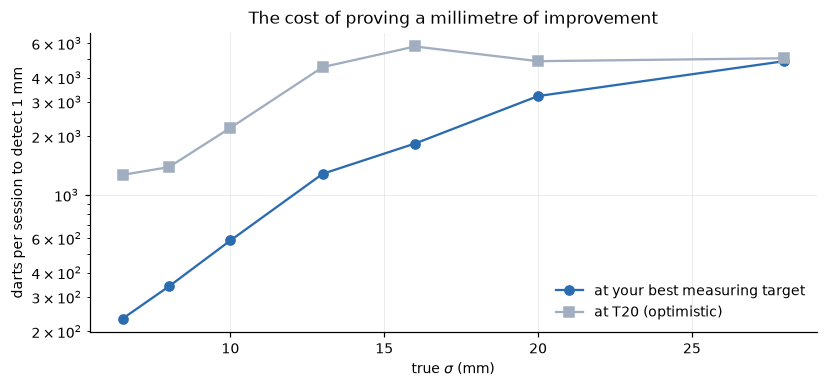

In [3]:
fig, ax = plt.subplots(figsize=(7.6, 3.6))
ax.plot(design.sigma_mm, [darts_to_detect(s, 1.0) for s in design.S_best],
        'o-', color='#2b6cb0', label='at your best measuring target')
ax.plot(design.sigma_mm, [darts_to_detect(s, 1.0) for s in design.S_T20],
        's-', color='#a0aec0', label='at T20 (optimistic)')
ax.set_yscale('log')
ax.set_xlabel(r'true $\sigma$ (mm)')
ax.set_ylabel('darts per session to detect 1 mm')
ax.set_title('The cost of proving a millimetre of improvement')
ax.legend()
fig.tight_layout()

The spread across abilities is a factor of twenty, and it runs the *opposite* way to
everything else in this project.

An **elite player can prove a millimetre in an evening**: 233 darts per session, before
and after. They are measured at the bull, where their tight scatter interacts with the
finest structure on the board, so their $S$ is small. A **pub player needs 4,857 darts per
session** -- roughly two weeks of dedicated nightly throwing, twice -- to prove the same
millimetre, even at their best measuring target. Detecting the half-millimetre a
realistic month of practice might actually deliver costs four times more again.

And that is with the *right* target. At T20, where nearly everyone would instinctively
run the before-and-after test, the cost multiplies by three to five: 5,800 darts per
session for a league player against 1,837, and 1,270 for an elite one against 233. The
choice of measuring target from notebook 09 does not change whether the question is
answerable, but it does change an evening into a week.

## Worth much, provable slowly

The uncomfortable part is putting the detection cost next to what the improvement is
*worth*. Notebook 08 found a millimetre buys roughly half a visit per leg at every
ability -- the value is flat. The detection cost is anything but.

,sigma,visits per leg per mm,darts per session to detect 1mm
0,6.5,0.435,232
1,8.0,0.448,340
2,10.0,0.488,585
3,13.0,0.547,1285
4,16.0,0.572,1837
5,20.0,0.570,3218
6,28.0,0.569,4857


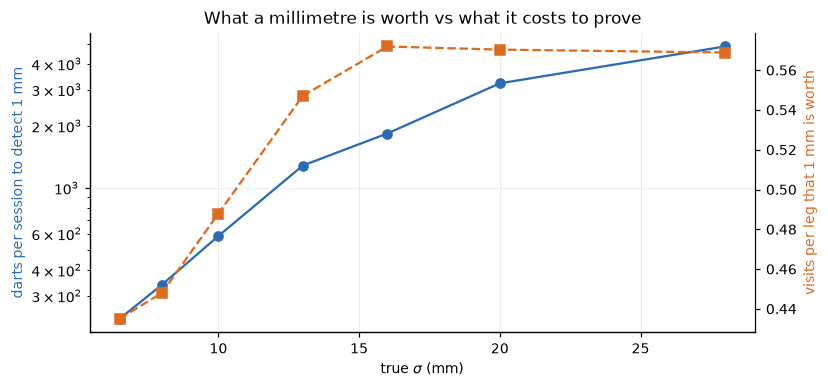

In [4]:
single = pd.read_csv(os.path.join(RESULTS, 'manifest_single_player.csv'))
vis = single[single.objective == 'visits'].sort_values('sigma_mm')

# visits gained per mm of improvement, by central difference on the band curve
sig = vis.sigma_mm.values
v = vis.value_501.values
worth = np.gradient(v, sig)          # visits per leg per mm

fig, ax1 = plt.subplots(figsize=(7.6, 3.6))
ax1.plot(sig, [darts_to_detect(s, 1.0) for s in design.sort_values('sigma_mm').S_best],
         'o-', color='#2b6cb0')
ax1.set_yscale('log')
ax1.set_xlabel(r'true $\sigma$ (mm)')
ax1.set_ylabel('darts per session to detect 1 mm', color='#2b6cb0')
ax2 = ax1.twinx()
ax2.plot(sig, worth, 's--', color='#dd6b20')
ax2.set_ylabel('visits per leg that 1 mm is worth', color='#dd6b20')
ax2.spines['right'].set_visible(True)
ax2.grid(False)
ax1.set_title('What a millimetre is worth vs what it costs to prove')
fig.tight_layout()

pd.DataFrame({'sigma': sig, 'visits per leg per mm': worth.round(3),
              'darts per session to detect 1mm':
                  [int(darts_to_detect(s, 1.0))
                   for s in design.sort_values('sigma_mm').S_best]})

The two curves are close to mirror images. What a millimetre is *worth* is flat --
0.44 to 0.57 visits per leg across the whole ability range, notebook 08's result restated
-- while what it costs to *prove* rises twenty-fold from elite to pub.

So the players who gain most per millimetre, and who have the most millimetres available
to gain, are precisely the ones who cannot verify their progress. A club player's
practice month is worth about half a visit per leg per millimetre -- a genuinely large
competitive change -- and is invisible to any testing regime they would plausibly submit
to. Meanwhile the elite player, whose millimetre is scarcer and worth slightly less per
leg, can confirm it in a single evening.

The practical reading is not "testing is pointless" but "single-session testing is the
wrong instrument below county level". What a weaker player's data can support is
*trend* estimation -- many small sessions across months, pooled -- rather than a
before-and-after verdict.

## Checking the formula against actual fits

The $n$ from the formula assumes the estimator achieves its asymptotic standard error and
is unbiased. Neither is exactly true, so: simulate the whole protocol at the league band --
two sessions of the prescribed length at the best target, both fitted by EM, a z-test on
the difference -- once where the player truly improved by 1 mm, and once where they did not
improve at all.

In [5]:
from statistics import NormalDist
from darts.dartboards import generate_dartboard
from darts.fitting import fit_multi_target, simulate_session

league = design[design.band == 'league'].iloc[0]
S = league.S_best
n = int(np.ceil(darts_to_detect(S, 1.0)))
target_mm = np.array([0.0, league.best1_r_mm])
PIXELS = 512
board, _ = generate_dartboard(PIXELS)
z_crit = NormalDist().inv_cdf(0.975)
print(f'league: S = {S:.1f}, so n = {n} darts per session; '
      f'target at r = {league.best1_r_mm:.0f} mm')

def one_trial(seed, sigma_before, sigma_after):
    rng = np.random.default_rng(seed)
    est = []
    for s_true in (sigma_before, sigma_after):
        sess = simulate_session([target_mm], n, np.zeros(2),
                                s_true ** 2 * np.eye(2), board=board,
                                seed=int(rng.integers(1 << 31)))
        est.append(fit_multi_target(sess, board=board)['sigma_mm'])
    z = (est[0] - est[1]) / (S * np.sqrt(2 / n))
    return z > z_crit          # one-sided detection of an improvement

reps = 80
improved = np.mean([one_trial(s, 16.0, 15.0) for s in range(reps)])
same = np.mean([one_trial(10_000 + s, 16.0, 16.0) for s in range(reps)])
print(f'\ndetection rate when truly improved 16 -> 15 mm : {improved:.2f}  '
      f'(designed for 0.80)')
print(f'false alarm rate when nothing changed          : {same:.2f}  '
      f'(designed for 0.025 one-sided)')

league: S = 10.8, so n = 1838 darts per session; target at r = 136 mm



detection rate when truly improved 16 -> 15 mm : 0.80  (designed for 0.80)
false alarm rate when nothing changed          : 0.01  (designed for 0.025 one-sided)


The formula survives contact with the estimator: designed for 80% power, the simulated
protocol detects the true 1 mm improvement 80% of the time. The false-alarm rate comes
out *below* its nominal level (1% observed against 2.5% designed) -- the estimator's
small residual bias is shared by both sessions and cancels in the difference, and at
1,840 darts per session the asymptotics have long since taken hold at this target.

So the darts counts in the table above are real requirements, not asymptotic
optimism -- with the standing exception of the T20 column.

## What to do with this

* **Test at your measuring target, not at T20.** The entire feasibility of the question
  depends on it: proving a millimetre costs a league player 1,837 darts per session at
  the big single, and 5,778 at T20.
* **Test against a baseline you already own.** If last month's session is treated as a
  known baseline rather than re-estimated, the requirement halves (the
  "vs known baseline" column). A standing habit of one measured session per month makes
  every later comparison cheaper.
* **Below county level, stop expecting verdicts from single sessions.** A club player's
  plausible monthly improvement is under the resolution of any one session they would
  realistically throw. The right instrument is a running fit across many ordinary
  sessions -- which is exactly what the next notebook builds: a posterior over $\sigma$
  that every dart of match play updates, so the evidence accumulates without any
  dedicated testing at all.
* **The asymmetry is worth internalising.** "I've been practising for a month and my
  average hasn't moved" is, for most players, exactly what genuine improvement looks
  like. The average is a noisier statistic than $\hat\sigma$ from a designed session,
  and even that cannot see a month of progress below league level.